# Mini-GPT para análisis de sentimiento en reseñas de comida

- Curso: Electiva NLP
- Institución: EAM
- Integrantes: Pablo Garcés, Alejandra Mejía, Sebastián Sosa
- Docente: Robert Erick García Rey


## 1. Descripción del proyecto

Este notebook demuestra el proyecto final **mini-gpt-sentiment**, un Mini-GPT didáctico para análisis de sentimiento en reseñas de comida.

El sistema clasifica textos como `positive` o `negative` usando el dataset **BD Food Review Dataset**. El modelo no es un GPT grande ni un generador de texto completo; es una arquitectura tipo GPT reducida y adaptada a clasificación supervisada de sentimiento.

En esta demostración se usa el checkpoint ya entrenado. No se descarga el dataset ni se entrena nuevamente el modelo.


## 2. Configuración inicial

Se configura la raíz del proyecto para poder importar los módulos existentes en `src/` desde el notebook.


In [2]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/pablogarceshoyos/Trabajo FInal NLP/mini-gpt-sentiment')

## 3. Archivos principales del proyecto

Se verifica que existan los artefactos necesarios para la demostración: checkpoint, tokenizer, mapeo de etiquetas, métricas y figuras.


In [3]:
required_files = [
    "models/mini_gpt_sentiment_best_weighted.pt",
    "data/processed/tokenizer.json",
    "data/processed/label_mapping.json",
    "reports/evaluation_metrics.json",
    "reports/figures/confusion_matrix_test.png",
    "reports/figures/final_metrics_barplot.png",
]

file_status = []
for relative_path in required_files:
    path = PROJECT_ROOT / relative_path
    file_status.append({
        "archivo": relative_path,
        "estado": "existe" if path.exists() else "no existe",
    })

display(pd.DataFrame(file_status))


,archivo,estado
0,models/mini_gpt_sentiment_best_weighted.pt,existe
1,data/processed/tokenizer.json,existe
2,data/processed/label_mapping.json,existe
3,reports/evaluation_metrics.json,existe
4,reports/figures/confusion_matrix_test.png,existe
5,reports/figures/final_metrics_barplot.png,existe


## 4. Resultados finales de evaluación

Resultados confirmados sobre `test.csv`:

- Accuracy: 0.906815
- Precision macro: 0.901750
- Recall macro: 0.899010
- F1 macro: 0.900337
- F1 weighted: 0.906656
- Errores: 3060


In [4]:
metrics_path = PROJECT_ROOT / "reports/evaluation_metrics.json"

with metrics_path.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

metric_keys = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]

metrics_table = []
for key in metric_keys:
    if key in metrics:
        metrics_table.append({"métrica": key, "valor": metrics[key]})

display(pd.DataFrame(metrics_table))
print(f"Ejemplos evaluados: {metrics.get('num_examples', 'no disponible')}")
print(f"Checkpoint: {metrics.get('checkpoint', 'no disponible')}")
print(f"Device: {metrics.get('device', 'no disponible')}")


,métrica,valor
0,accuracy,0.906815
1,precision_macro,0.901750
2,recall_macro,0.899010
3,f1_macro,0.900337
4,f1_weighted,0.906656


Ejemplos evaluados: 32838
Checkpoint: models/mini_gpt_sentiment_best_weighted.pt
Device: mps


## 5. Figuras del entrenamiento y evaluación

Se muestran las figuras disponibles de entrenamiento y evaluación. Si alguna figura no existe, se informa sin detener el notebook.


**reports/figures/training_loss_curve.png**

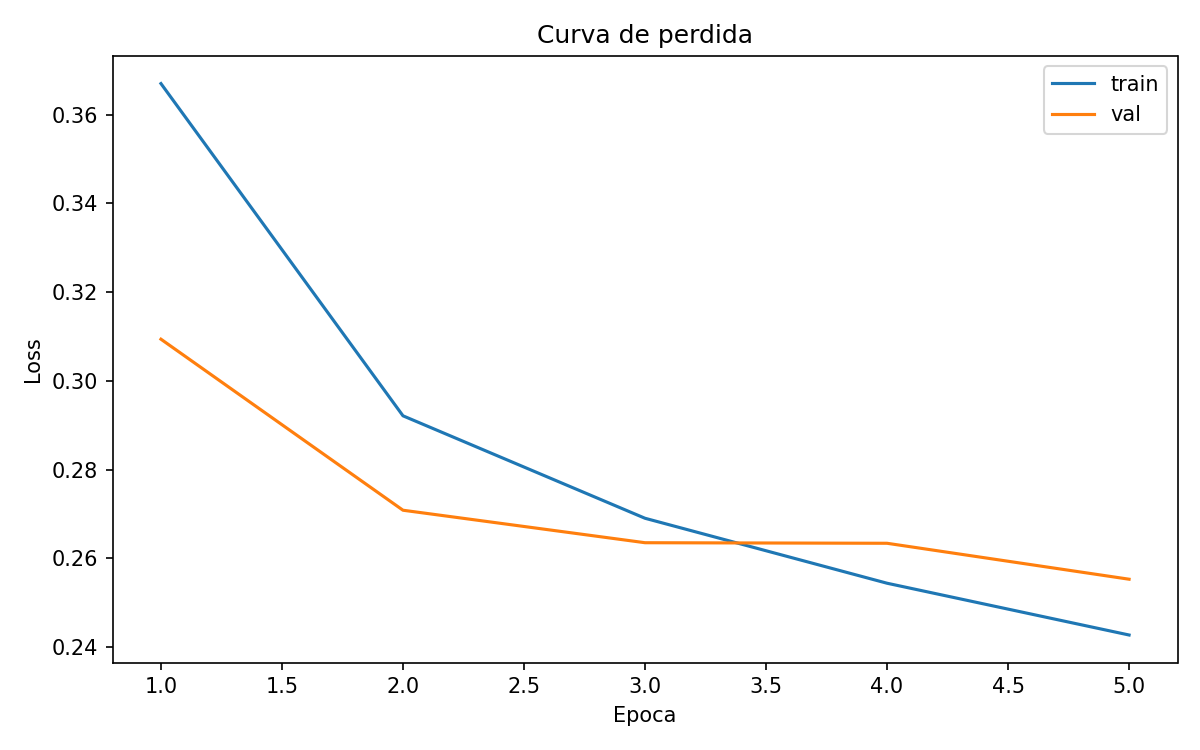

**reports/figures/training_accuracy_curve.png**

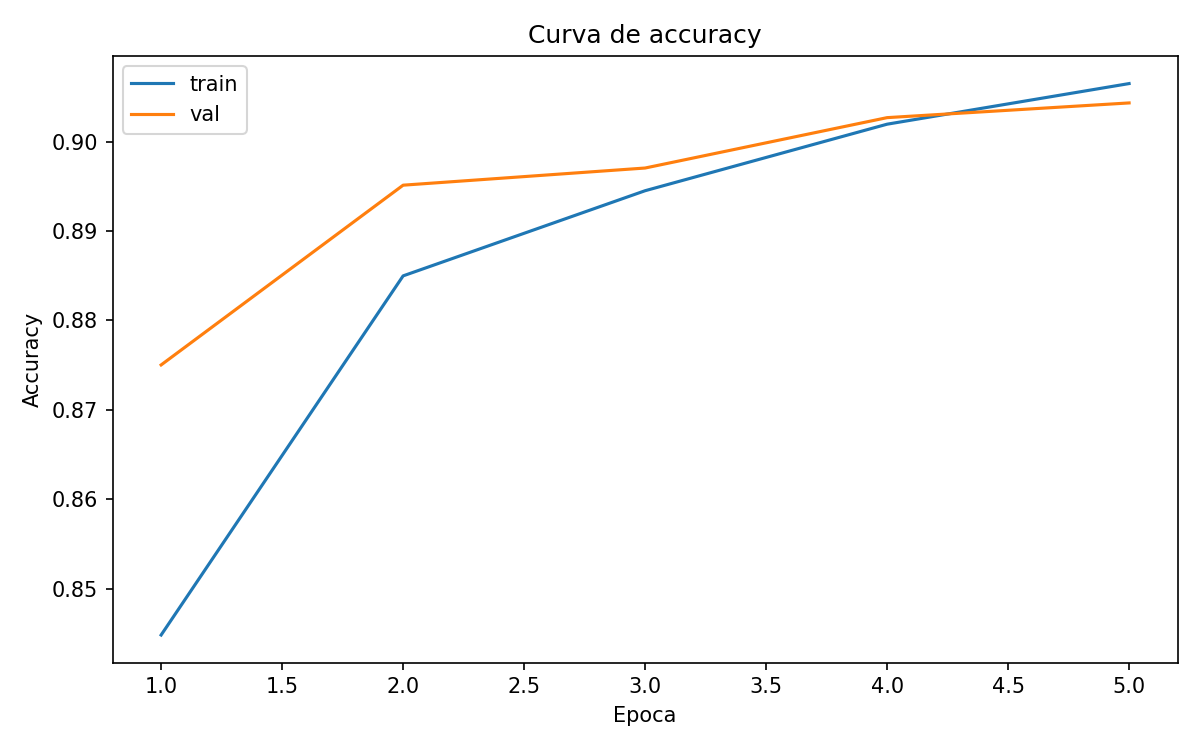

**reports/figures/training_f1_curve.png**

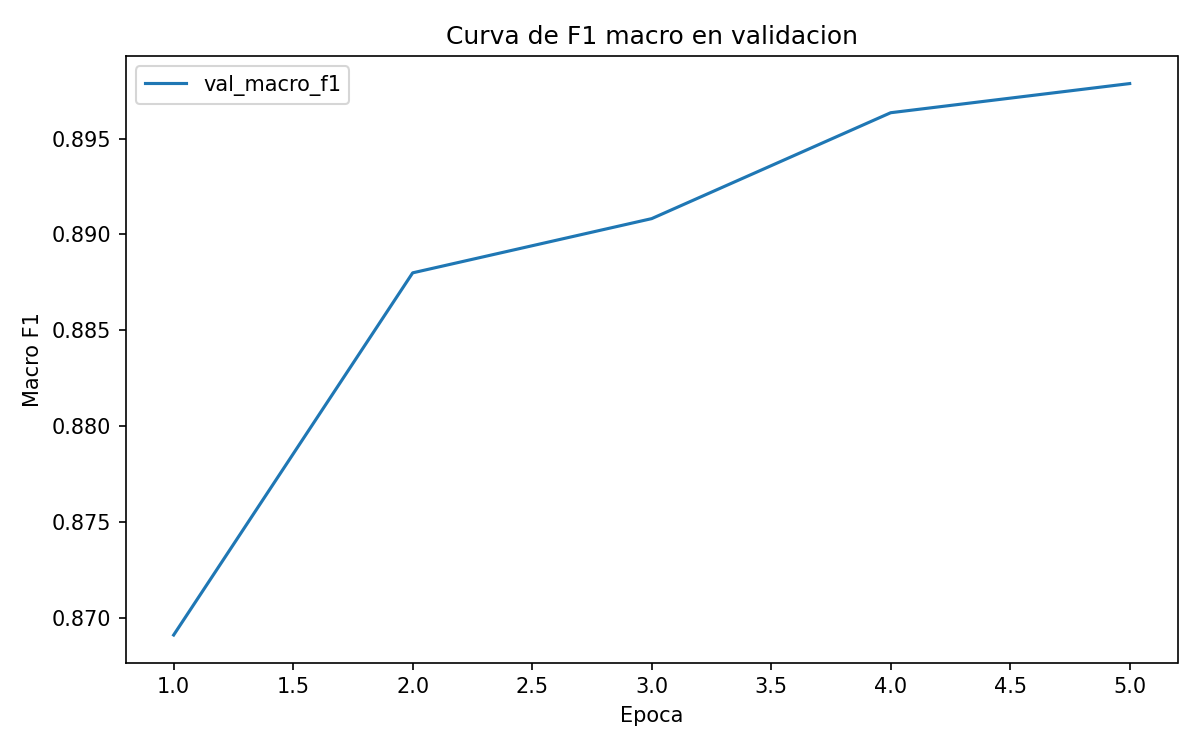

**reports/figures/confusion_matrix_test.png**

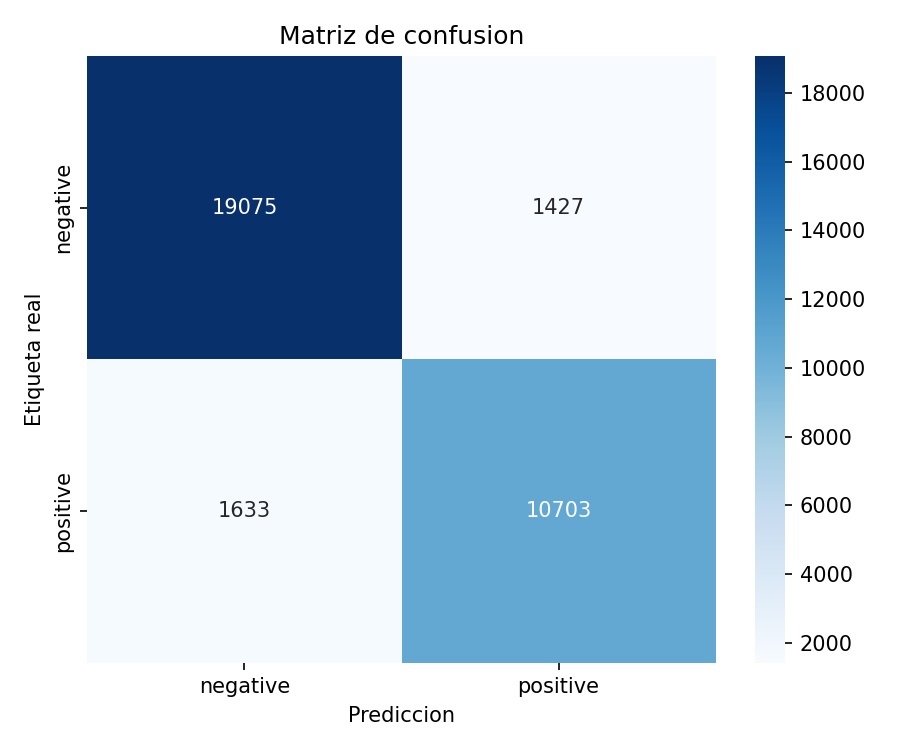

**reports/figures/final_metrics_barplot.png**

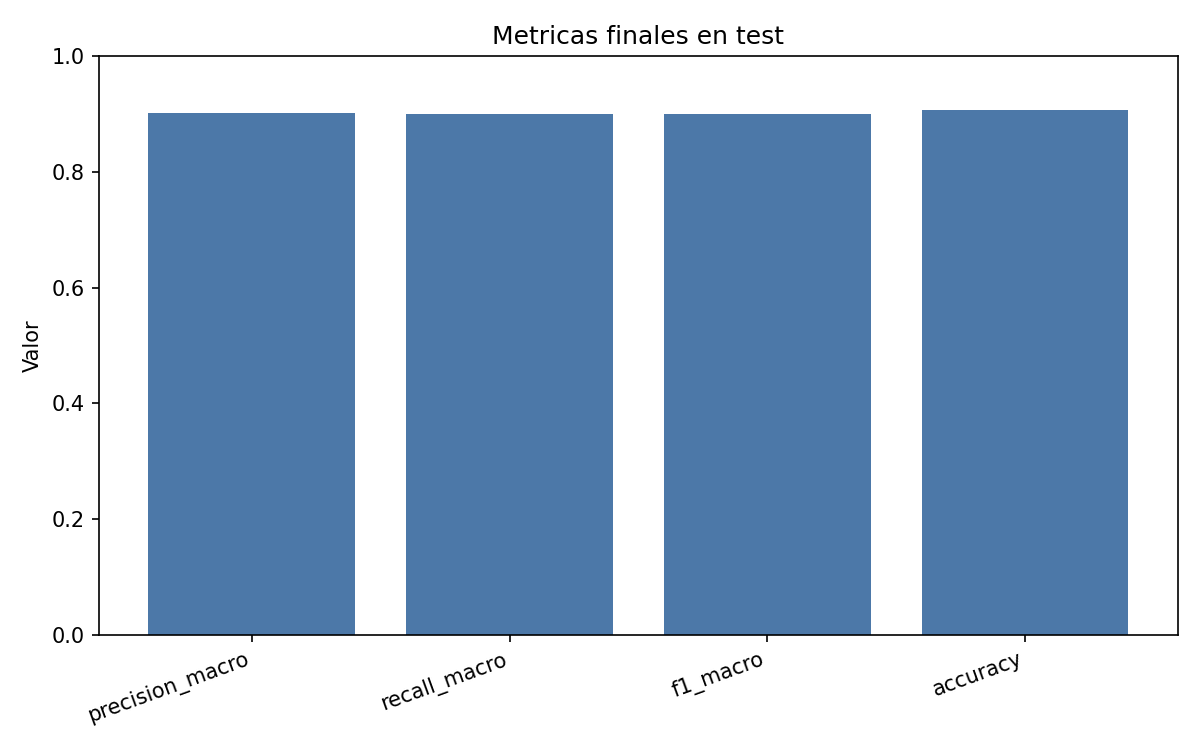

In [5]:
figure_paths = [
    "reports/figures/training_loss_curve.png",
    "reports/figures/training_accuracy_curve.png",
    "reports/figures/training_f1_curve.png",
    "reports/figures/confusion_matrix_test.png",
    "reports/figures/final_metrics_barplot.png",
]

for relative_path in figure_paths:
    figure_path = PROJECT_ROOT / relative_path
    if figure_path.exists():
        display(Markdown(f"**{relative_path}**"))
        display(Image(filename=str(figure_path), width=700))
    else:
        print(f"No existe la figura: {relative_path}")


## 6. Tokenizer y vocabulario

El proyecto usa `SimpleTokenizer`, un tokenizador didáctico basado en expresiones regulares. El vocabulario fue construido únicamente con `train.csv` para evitar fuga de información.

- Tamaño final del vocabulario: 16612
- MAX_CONTEXT_LENGTH: 128
- Tokens especiales: `<PAD>`, `<UNK>`, `<BOS>`, `<EOS>`


In [6]:
from src.tokenizer import SimpleTokenizer

tokenizer = SimpleTokenizer.load(PROJECT_ROOT / "data/processed/tokenizer.json")

special_tokens = pd.DataFrame([
    {"token": tokenizer.pad_token, "id": tokenizer.pad_token_id},
    {"token": tokenizer.unk_token, "id": tokenizer.unk_token_id},
    {"token": tokenizer.bos_token, "id": tokenizer.bos_token_id},
    {"token": tokenizer.eos_token, "id": tokenizer.eos_token_id},
])

print(f"Tamaño del vocabulario: {tokenizer.vocab_size}")
display(special_tokens)

example_text = "The food was delicious"
example_tokens = tokenizer.basic_tokenize(example_text)
example_ids = tokenizer.encode(example_text)

display(pd.DataFrame({
    "texto": [example_text],
    "tokens": [example_tokens],
    "ids": [example_ids],
}))


Tamaño del vocabulario: 16612


,token,id
0,<PAD>,0
1,<UNK>,1
2,<BOS>,2
3,<EOS>,3


,texto,tokens,ids
0,The food was delicious,"[the, food, was, delicious]","[2, 4, 8, 5, 101, 3]"


## 7. Arquitectura del Mini-GPT

La arquitectura incluye embeddings de tokens, embeddings posicionales aprendidos, atención causal multi-cabeza, bloques Transformer decoder y una cabeza de clasificación. Para clasificar se usa la representación del último token válido de la secuencia según `attention_mask`.


In [7]:
from src.model import create_model_from_config

model = create_model_from_config(vocab_size=tokenizer.vocab_size, num_classes=2)
model_config = model.get_model_config()
parameter_counts = model.count_parameters()

display(pd.DataFrame(list(model_config.items()), columns=["parámetro", "valor"]))
display(pd.DataFrame([
    {"tipo": "parámetros totales", "cantidad": parameter_counts["total"]},
    {"tipo": "parámetros entrenables", "cantidad": parameter_counts["trainable"]},
]))


,parámetro,valor
0,vocab_size,16612.0
1,max_context_length,128.0
2,embed_dim,128.0
3,num_heads,4.0
4,num_layers,2.0
5,num_classes,2.0
6,dropout,0.1
7,pad_token_id,0.0


,tipo,cantidad
0,parámetros totales,2539778
1,parámetros entrenables,2539778


## 8. Predicción de frases nuevas

Se carga el checkpoint entrenado y se clasifican tres frases nuevas. Las probabilidades se calculan con softmax sobre los logits del modelo.


In [8]:
from src.predict import load_prediction_assets, predict_sentiment
from src.utils import get_device

device = get_device()
checkpoint_path = PROJECT_ROOT / "models/mini_gpt_sentiment_best_weighted.pt"
model, tokenizer, label_mapping, id_to_label = load_prediction_assets(checkpoint_path, device)

texts = [
    "The food was delicious and the service was excellent",
    "The food was terrible and the delivery was very late",
    "I will order again because everything was perfect",
]

prediction_rows = []
for text in texts:
    result = predict_sentiment(
        text=text,
        model=model,
        tokenizer=tokenizer,
        id_to_label=id_to_label,
        device=device,
        max_length=128,
    )
    prediction_rows.append({
        "texto": result["text"],
        "predicted_label": result["predicted_label"],
        "confidence": result["confidence"],
        "prob_negative": result["probabilities"].get("negative"),
        "prob_positive": result["probabilities"].get("positive"),
    })

print(f"Device usado: {device}")
display(pd.DataFrame(prediction_rows))


Device usado: mps


,texto,predicted_label,confidence,prob_negative,prob_positive
0,The food was delicious and the service was exc...,positive,0.998282,0.001718,0.998282
1,The food was terrible and the delivery was ver...,negative,0.993051,0.993051,0.006949
2,I will order again because everything was perfect,positive,0.997110,0.002890,0.997110


## 9. Cómo reproducir el entrenamiento

El entrenamiento completo no se ejecuta dentro de este notebook. El checkpoint ya entrenado se encuentra en `models/mini_gpt_sentiment_best_weighted.pt`.

Comando usado para el entrenamiento final:

```bash
python3 -m src.train \
  --epochs 5 \
  --batch-size 32 \
  --learning-rate 3e-4 \
  --use-class-weights \
  --checkpoint-name mini_gpt_sentiment_best_weighted.pt \
  --last-checkpoint-name mini_gpt_sentiment_last_weighted.pt
```

El entrenamiento completo puede tardar dependiendo del dispositivo disponible.


## 10. Cómo evaluar desde consola

La evaluación final sobre `test.csv` puede reproducirse con:

```bash
python3 -m src.evaluate --checkpoint models/mini_gpt_sentiment_best_weighted.pt
```


## 11. Limitaciones

- El modelo fue entrenado principalmente con textos en inglés o normalizados en inglés.
- Las predicciones en español no son completamente confiables sin traducción o entrenamiento adicional.
- La configuración principal es binaria y no incluye la clase neutral.
- El tokenizador es didáctico y no usa subpalabras.
- El modelo puede fallar con ironía, ambigüedad, reseñas mixtas o ruido en etiquetas.


## 12. Conclusión

El Mini-GPT logró clasificar sentimiento en reseñas de comida con un F1 macro final de 0.900337 sobre `test.csv`. El sistema permite ejecutar predicciones sobre frases nuevas y cumple el objetivo académico de aplicar tokenización, embeddings, atención causal y una arquitectura Transformer tipo GPT a una tarea de NLP supervisada.
